In [14]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve
import sklearn

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel



from morbius import make_mobius_strip
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
def plot3d(d, title):
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [16]:
import numpy as np

n_samples = 2000

X_mobius, _  = make_mobius_strip(n_samples=2000, radius = 2, width = 3, noise=0.2)

plot3d(X_mobius, "Möbius Strip")

In [17]:
X_S, t = make_s_curve(noise=0.10, random_state=0, n_samples=1000)
plot3d(X_S, "Curve Data")

In [18]:
X = X_S # Choose dataset
lr=5.0e-3
hidden_dim = 5
z_dim = 2
adam = optim.Adam(lr)



# Basic VAE

In [19]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )


def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn())
    )


def model(batch, hidden_dim=5, z_dim=2, inference=False, **kwargs):
    batch = jnp.reshape(batch, (batch.shape[0], -1))
    batch_dim, out_dim = jnp.shape(batch)
    
    decode = numpyro.module("decoder", decoder(hidden_dim, out_dim), (batch_dim, z_dim))
    
    with numpyro.plate("batch", batch_dim):

        z = numpyro.sample("z", dist.Normal(0, 1).expand([z_dim]).to_event(1))
        
        img_loc = decode(z)
        
        numpyro.deterministic("clean", img_loc)
        
        return numpyro.sample(
            "obs", 
            dist.Normal(img_loc, scale=0.1).to_event(1), 
            obs=(None if inference else batch)
        )


def guide(batch, hidden_dim=5, z_dim=2, **kwargs):
    batch = jnp.reshape(batch, (batch.shape[0], -1))
    batch_dim, out_dim = jnp.shape(batch)
    encode = numpyro.module("encoder", encoder(hidden_dim, z_dim), (batch_dim, out_dim))
    z_loc, z_std = encode(batch)
    with numpyro.plate("batch", batch_dim):
        return numpyro.sample("z", dist.Normal(z_loc, z_std).to_event(1))


In [20]:
X = jnp.array(X)

svi = SVI(model,guide,adam, Trace_ELBO())

rng_key, sub_key = jax.random.split(rng_key)
svi_result = svi.run(sub_key, 1000, batch=X, hidden_dim=hidden_dim, z_dim = z_dim)

100%|██████████| 1000/1000 [00:05<00:00, 178.70it/s, init loss: 188632.2812, avg. loss [951-1000]: 20414.8535]


In [21]:
rng_key, sub_key = jax.random.split(rng_key)


def samples(model, guide = None, clean=False):
    predictive = Predictive(
        model, 
        guide=guide, 
        params=svi_result.params, 
        num_samples=1,
        return_sites=["z", "clean", "obs", "m"]
    )

    predictions = predictive(sub_key, batch=X, hidden_dim=hidden_dim, z_dim=z_dim, inference=True)

    reconstructed = predictions["obs"][0]
    if clean:
        reconstructed = predictions["clean"][0]

    if guide:
        title = "reconstructed"
    else:
        title = "samples"

    plot3d(reconstructed, title)
    return predictions

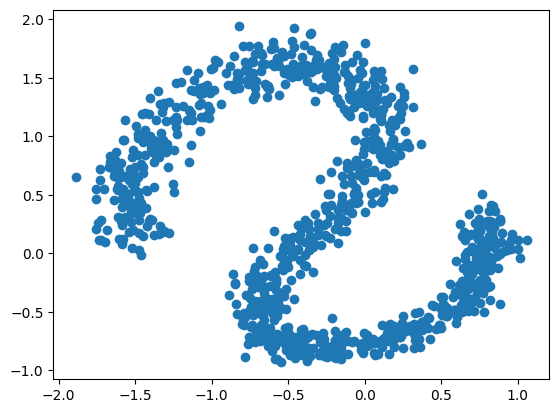

In [22]:
predictions = samples(model, guide)
if z_dim == 2:
    zs = predictions["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])


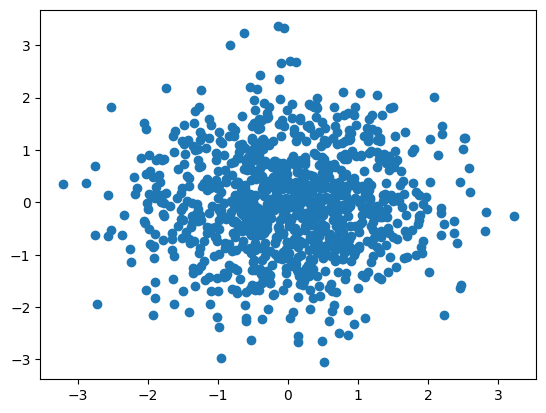

In [23]:
predictions = samples(model, None)
if z_dim == 2:
    zs = predictions["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])


# A global Parameter


In [24]:
def model(batch, hidden_dim=5, z_dim=2, inference=False, **kwargs):
    batch = jnp.reshape(batch, (batch.shape[0], -1))
    batch_dim, out_dim = jnp.shape(batch)
    
    decode = numpyro.module("decoder", decoder(hidden_dim, out_dim), (batch_dim, z_dim))


    m = numpyro.sample("m", dist.Normal(0, 1).expand([z_dim]).to_event())

    global_dist = dist.Normal(m, 1)
    
    with numpyro.plate("batch", batch_dim):

        z = numpyro.sample("z", global_dist.to_event(1))
        
        img_loc = decode(z)
        
        numpyro.deterministic("clean", img_loc)
        
        return numpyro.sample(
            "obs", 
            dist.Normal(img_loc, scale=0.1).to_event(1), 
            obs=(None if inference else batch)
        )


def guide(batch, hidden_dim=400,  z_dim = 50, **kwargs):
    batch = jnp.reshape(batch, (batch.shape[0], -1))
    batch_dim, out_dim = jnp.shape(batch)
    
    a = numpyro.param("a", jnp.zeros(z_dim))
    B = numpyro.param("B", jnp.ones(z_dim), constraint=dist.constraints.positive)

    m = numpyro.sample("m", dist.Normal(a, B).to_event())

    encode = numpyro.module("encoder", encoder(hidden_dim, z_dim), (batch_dim, out_dim + z_dim))


    # Concatanate it for the encoder
    tiled = jnp.tile(m, (batch_dim, 1))
    concat_input = jnp.concat([batch, tiled], axis=1)


    z_loc, z_std = encode(concat_input)
    with numpyro.plate("batch", batch_dim):
        d = dist.Normal(z_loc, z_std).to_event(1)
        
        z = numpyro.sample("z", d)
        return z

In [25]:
X = jnp.array(X)


svi = SVI(model,guide,adam, Trace_ELBO())


rng_key, sub_key = jax.random.split(rng_key)
svi_result = svi.run(sub_key, 1000, batch=X, hidden_dim=hidden_dim, z_dim = z_dim)

100%|██████████| 1000/1000 [00:06<00:00, 160.45it/s, init loss: 188310.2812, avg. loss [951-1000]: 21339.8750]


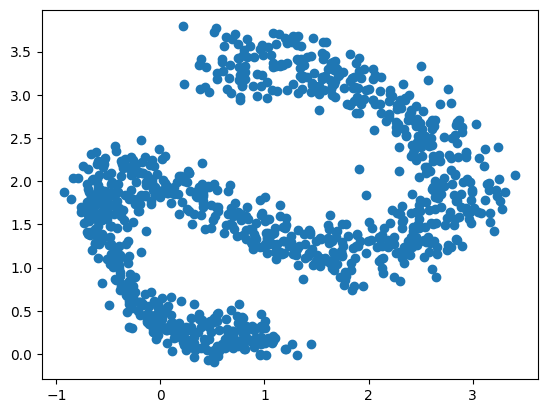

In [26]:
predictions_g = samples(model, guide)
if z_dim == 2:
    zs = predictions_g["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])

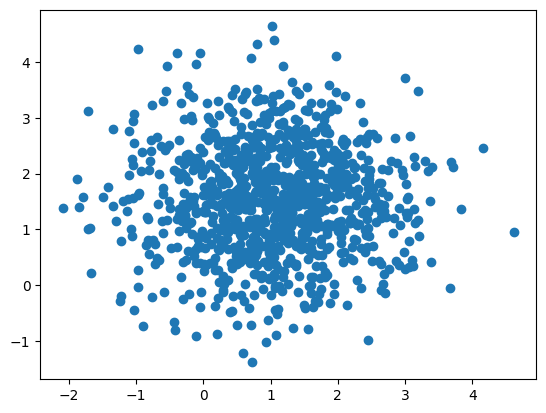

In [27]:

predictions = numpyro.handlers.substitute(samples, data={"m": predictions_g["m"][0]})(model, None)
if z_dim == 2:
    zs = predictions["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])


# Adding a normalizing flow

In [28]:
def model(batch, hidden_dim=5, z_dim=2, inference=False, **kwargs):
    batch = jnp.reshape(batch, (batch.shape[0], -1))
    batch_dim, out_dim = jnp.shape(batch)
    
    decode = numpyro.module("decoder", decoder(hidden_dim, out_dim), (batch_dim, z_dim))

    d = dist.Normal(0, 1).expand([z_dim]).to_event()
    m = numpyro.sample("m", d)


    # Configue Flow
    flow_transform = numpyro.module(
        "flow", 
        normalizing_flow(
            input_dim=z_dim, 
            hidden_dims=[10, 10],
            steps=10,
            inv = False
        ),
        input_shape=(batch_dim, z_dim)
    )()

    

    m_dist = dist.Normal(m, 1)
    flow_dist = dist.TransformedDistribution(m_dist, flow_transform)
    assert(flow_dist.batch_shape == () )
    

    with numpyro.plate("batch", batch_dim):

        z = numpyro.sample("z", flow_dist)
                
        img_loc = decode(z)
        
        numpyro.deterministic("clean", img_loc)
        
        return numpyro.sample(
            "obs", 
            dist.Normal(img_loc, scale=0.1).to_event(1), 
            obs=(None if inference else batch)
        )


def guide(batch, hidden_dim=400,  z_dim = 50, **kwargs):
    batch = jnp.reshape(batch, (batch.shape[0], -1))
    batch_dim, out_dim = jnp.shape(batch)
    
    a = numpyro.param("a", jnp.zeros(z_dim))
    B = numpyro.param("B", jnp.ones(z_dim), constraint=dist.constraints.positive)
    print("a", a.shape)

    m = numpyro.sample("m", dist.Normal(a, B).to_event())
   

    encode = numpyro.module("encoder", encoder(hidden_dim, z_dim), (batch_dim, out_dim + z_dim))


    # Concatanate it for the encoder
    tiled = jnp.tile(m, (batch_dim, 1))
    concat_input = jnp.concat([batch, tiled], axis=1)


    z_loc, z_std = encode(concat_input)
    with numpyro.plate("batch", batch_dim):
        d = dist.Normal(z_loc, z_std).to_event(1)
        
        z = numpyro.sample("z", d)
        return z

In [29]:
X = jnp.array(X)

svi = SVI(model,guide,adam, Trace_ELBO())


rng_key, sub_key = jax.random.split(rng_key)
svi_result = svi.run(sub_key, 2000, batch=X, hidden_dim=hidden_dim, z_dim = z_dim)

a (2,)


  0%|          | 0/2000 [00:00<?, ?it/s]

a (2,)


100%|██████████| 2000/2000 [00:54<00:00, 36.76it/s, init loss: 903977.8125, avg. loss [1901-2000]: 43486.8203] 


a (2,)


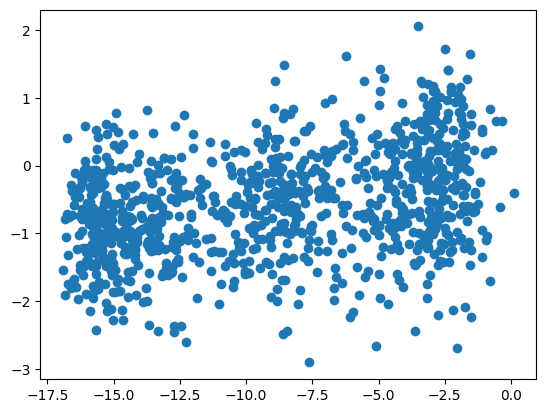

In [30]:
predictions_g = samples(model, guide, True)
if z_dim == 2:
    zs = predictions_g["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])

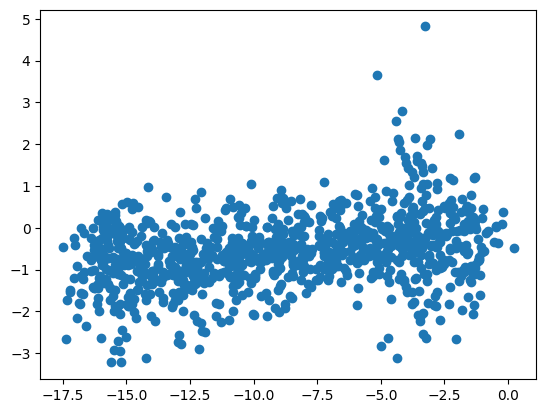

In [31]:
predictions = numpyro.handlers.substitute(samples, data={"m": predictions_g["m"][0]})(model, None)
if z_dim == 2:
    zs = predictions["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])


# Implementing the stein mixture


In [32]:

kernel = SingleSiteRBFKernel("a")
num_stein_particles=3

def non_stein(name):
    if name in ["a", "B"]:
        return False
    else:
        return True

In [33]:



stein = SteinVI(model,guide,adam, kernel, num_stein_particles=num_stein_particles, non_mixture_guide_params_fn=non_stein)


rng_key, sub_key = jax.random.split(rng_key)
stein_result = stein.run(sub_key, 2000, batch=X, hidden_dim=hidden_dim, z_dim = z_dim)

a (2,)
a (2,)
a (2,)
a (2,)
a (2,)
a (2,)


  0%|          | 0/2000 [00:00<?, ?it/s]

a (2,)
a (2,)
a (2,)
a (2,)


 57%|█████▋    | 1133/2000 [03:55<03:00,  4.81it/s, Stein force nan.]                   


KeyboardInterrupt: 

In [ ]:
def mixture_samples(model, guide = None, clean=False):
    global rng_key, num_stein_particles
    rng_key, sub_key = jax.random.split(rng_key)
    particle = jax.random.randint(sub_key, (), 0, num_stein_particles)
    params = dict(stein_result.params)

    print(particle)
    params["a"] = jax.tree.map(lambda x: x[particle], params["a"])
    params["B"] = jax.tree.map(lambda x: x[particle], params["B"])

    predictive = Predictive(
        model, 
        guide=guide, 
        params=params, 
        num_samples=1,
        return_sites=["z", "clean", "obs", "m"]
    )

    predictions = predictive(sub_key, batch=X, hidden_dim=hidden_dim, z_dim=z_dim, inference=True)

    reconstructed = predictions["obs"][0]
    if clean:
        reconstructed = predictions["clean"][0]

    if guide:
        title = "reconstructed"
    else:
        title = "samples"

    plot3d(reconstructed, title)
    return predictions

In [ ]:
predictions_g = mixture_samples(model, guide, True)
if z_dim == 2:
    zs = predictions["z"][0]
    plt.scatter(x=zs[:,0], y=zs[:,1])

0
a (3,)


In [ ]:
predictions = numpyro.handlers.substitute(mixture_samples, data={"m": predictions_g["m"][0]})(model, None, True)

1
